# Анализ продаж и потребительского поведения ресторана быстрого питания Balaji
📌 О контексте и целях проекта

Данный пет-проект представляет собой разведочный анализ данных (EDA) и проверку статистических гипотез на основе данных о транзакциях заведения быстрого питания Balaji.

Главная цель исследования — найти скрытые закономерности в поведении покупателей и сформулировать конкретные бизнес-рекомендации для увеличения выручки, оптимизации меню и эффективного управления персоналом.
📊 Описание датасета

В нашем распоряжении находится лог из 1000 транзакций. Датасет содержит следующие ключевые атрибуты:

    order_id — уникальный идентификатор заказа;

    date — дата совершения транзакции;

    item_name / item_type — название блюда и его категория (Fastfood / Beverages);

    item_price / quantity — цена за единицу и количество купленных товаров;

    transaction_amount — итоговая сумма чека;

    transaction_type — тип оплаты (Cash / Online);

    received_by — пол покупателя (Mr. / Mrs.);

    time_of_sale — время суток, когда был совершен заказ (Morning, Afternoon, Evening, Night, Midnight).

🎯 Бизнес-вопросы для исследования

В ходе работы мы проверим ряд гипотез и ответим на следующие вопросы:

    Анализ платежных систем: Какой тип оплаты преобладает, как он влияет на средний чек и меняется ли в зависимости от времени суток?

    Демография и структура корзины: Отличаются ли предпочтения и готовность тратить деньги у мужской и женской аудитории (с проверкой разницы средних чеков статистическими критериями)?

    Временные циклы и загруженность: Как меняется спрос в зависимости от времени суток и дней недели (будни vs выходные)? Оптимально ли распределяется нагрузка на персонал?

    Проверка консистентности данных: Присутствуют ли в итоговой сумме транзакций скрытые налоги, скидки или комиссии?

## Импортирование библиотек

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats    

orders = pd.read_csv(r'D:\balaji_orders\data\balaji_sales.csv')
orders.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


## Подготовка данных

In [2]:
# Проверка на дубликаты
print("Дублирующихся строк:")
print(orders.duplicated().sum()) # - Дубликатов строк не наблюдается
# Проверка на пропуски
print("Пропуски:")
print(orders.isna().sum()) # - Пропуски только в столбце "transaction_type"
orders['transaction_type'] = orders['transaction_type'].fillna('Unknown') # - Заполнение категорией "Unknown"
# Очистка и преобразование дат к нужному формату, создание нового столбца "day_of_week" (в числовом и строчном виде)
orders['date'] = orders['date'].astype(str).str.strip()
orders['date_dt'] = pd.to_datetime(orders['date'], dayfirst=False, format='mixed', errors='coerce')
orders['date_final'] = orders['date_dt'].dt.strftime('%d-%m-%Y')
orders['date_final'] = pd.to_datetime(orders['date_final'], dayfirst=True)
orders['day_of_week'] = orders['date_final'].dt.dayofweek
orders['day_of_week_str'] = orders['date_final'].dt.day_name()
orders = orders.drop(['date', 'date_dt'], axis=1)

Дублирующихся строк:
0
Пропуски:
order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64


Обработка пропущенных значений в transaction_type

В столбце payment_type обнаружено 107 пропусков (10.7%).

Решение: Было принято решение исключить данные строки из анализа взаимосвязи типов оплаты, так как:

    Доля пропусков относительно невелика и не препятствует получению статистически значимых выводов по оставшимся 893 записям.

    Заполнение (imputation) наиболее частым значением (Mode) может привести к смещению оценки, так как мы не можем достоверно восстановить предпочтения пользователя без дополнительных данных.

    Данные пропуски будут учитываться как категория "Unknown" при расчете общего объема транзакций, но исключаться при сравнении среднего чека по типам оплаты.

## Разведочный анализ (EDA)

In [3]:
orders.describe() # - базовые статистика

,order_id,item_price,quantity,transaction_amount,date_final,day_of_week
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000,2022-10-03 14:39:50.400000,3.082000
min,1.000000,20.000000,1.000000,20.000000,2022-04-01 00:00:00,0.000000
25%,250.750000,20.000000,4.000000,120.000000,2022-07-04 00:00:00,1.000000
50%,500.500000,25.000000,8.000000,240.000000,2022-10-07 12:00:00,3.000000
75%,750.250000,50.000000,12.000000,360.000000,2023-01-02 00:00:00,5.000000
max,1000.000000,60.000000,15.000000,900.000000,2023-03-30 00:00:00,6.000000
std,288.819436,14.921744,4.413075,204.402979,NaN,2.017262


In [4]:
orders.item_name.value_counts() # - топ самых заказываемых позиций

item_name
Cold coffee        161
Sugarcane juice    153
Panipuri           150
Frankie            139
Aalopuri           134
Vadapav            134
Sandwich           129
Name: count, dtype: int64

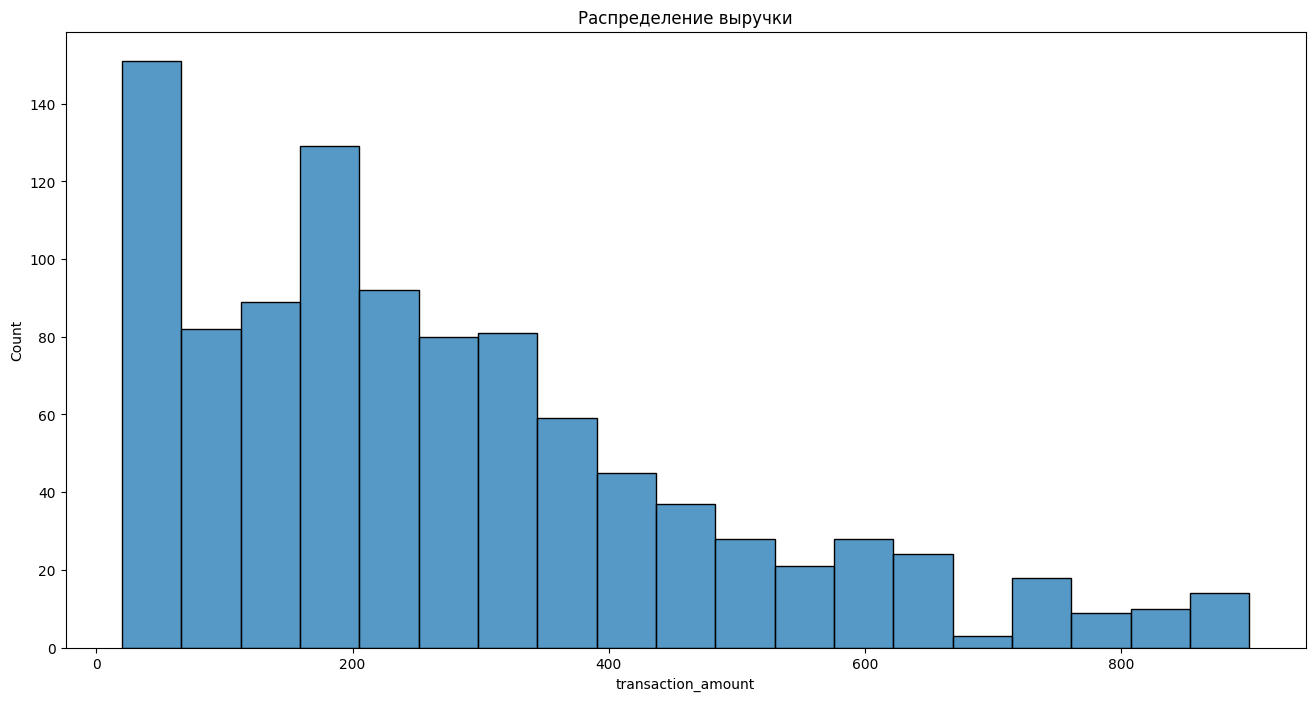

In [5]:
plt.figure(figsize=(16, 8))
sns.histplot(data=orders, x="transaction_amount")
plt.title('Распределение выручки')
plt.show()

In [6]:
top_items = orders.groupby('item_name').transaction_amount.sum().sort_values(ascending=False)
print('Топ позиций по выручке:')
print(top_items)

Топ позиций по выручке:
item_name
Sandwich           65820
Frankie            57500
Cold coffee        54440
Sugarcane juice    31950
Panipuri           24520
Aalopuri           20880
Vadapav            20120
Name: transaction_amount, dtype: int64


In [7]:
calculated_total = orders['item_price'] * orders['quantity']
diff_amount = orders['transaction_amount'] - calculated_total
hiden_costs = np.abs(diff_amount).sum()
print(f"Сумма всех комиссий, налогов и скидок (по модулю): {hiden_costs}")

Сумма всех комиссий, налогов и скидок (по модулю): 0


Отсюда получаем: скрытых комиссий, налогов и скидок нет.

## Проверка гипотез

### Платежные предпочтения

##### Гипотеза: Клиенты, выбирающие online оплату, имеют более высокий средний чек, чем те, кто платит cash.

Структура всей выручки:
transaction_type
Cash       48.27
Online     40.18
Unknown    11.55
Name: transaction_amount, dtype: float64

Сравнение среднего чека:
transaction_type
Cash      279.08
Online    265.22
Name: transaction_amount, dtype: float64


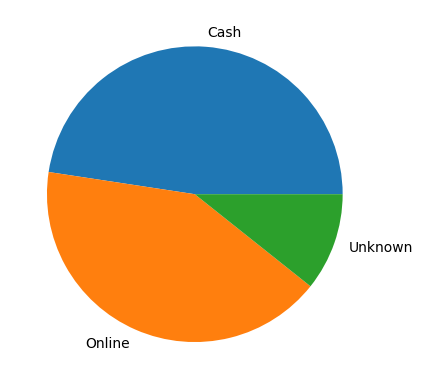

In [8]:
total_amount = orders.transaction_amount.sum()
props = (orders.groupby('transaction_type').transaction_amount.sum()) / total_amount * 100

print("Структура всей выручки:")
print(props.round(2))

print("\nСравнение среднего чека:") # - для подсчета среднего чека Unknown бесполезно 
clean_means = orders[orders.transaction_type != 'Unknown'].groupby('transaction_type').transaction_amount.mean()
print(clean_means.round(2))

cash_count = orders.transaction_type.value_counts()['Cash']
online_count = orders.transaction_type.value_counts()['Online']
unknown_count = orders.transaction_type.value_counts()['Unknown']

labels = ['Cash', 'Online', 'Unknown']
sizes = [cash_count, online_count, unknown_count ]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels);


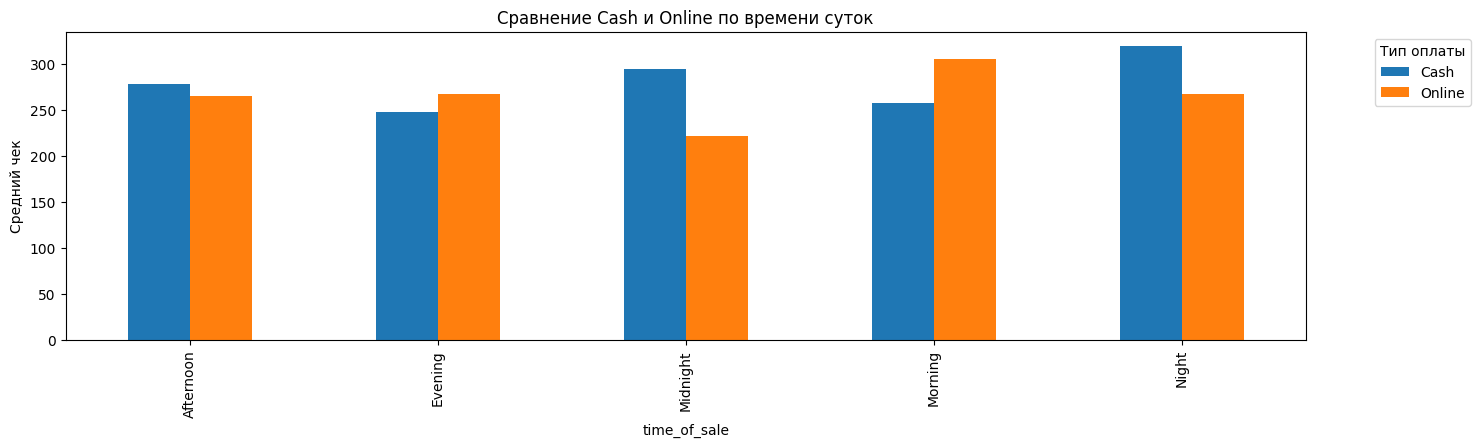

In [9]:
pivot_ret = orders[orders.transaction_type != 'Unknown'].pivot_table(index='time_of_sale', columns='transaction_type', values='transaction_amount', fill_value=0)
pivot_ret.plot(kind='bar', figsize=(16,4))
plt.title('Сравнение Cash и Online по времени суток')
plt.ylabel('Средний чек')
plt.legend(title='Тип оплаты', bbox_to_anchor=(1.05, 1), loc='upper left') # Выносим легенду за график
plt.show()

Вывод: по части общей выручки Cash > Online на 8%, по части среднего чека Cash > Online на ~ 14 денежные единицы, это может быть связано с тем, что в этой стране наличные деньги популярнее остальных видов оплаты (специфика страны). Высокая доля наличных несет риски инкассации и замедляет кассу. 

Рекомендация: Ввести скидку в 2% для онлайн-оплат, чтобы ускорить пропускную способность.



#### Гипотеза: Возможно, ночные заказы чаще оплачивают онлайн из соображений безопасности?

In [10]:
time_of_sale_check = orders.groupby(['transaction_type', 'time_of_sale']).transaction_amount.count().unstack()
time_of_sale_check

time_of_sale,Afternoon,Evening,Midnight,Morning,Night
transaction_type,,,,,
Cash,91,103,98,92,92
Online,90,82,79,76,90
Unknown,24,16,22,22,23


Нет, ночные заказы чаще оплачивают кешем, но разница небольшая (2 заказа). Вечером же (в часы пиковой нагрузки) преобладает оплата наличными, что потенциально замедляет пропускную способность касс из-за необходимости выдавать сдачу.

Бизнес-рекомендация: Чтобы разгрузить очереди вечером, необходимо стимулировать безналичную оплату. Возможные решения:
- Ввести акцию «Скидка 3% при оплате картой/онлайн после 18:00».
- Если в заведении есть терминалы самообслуживания (киоски), поставить рядом с ними сотрудника, который будет направлять туда поток людей.

### Демографический профиль и потребительская корзина

In [11]:
gender_count = orders.groupby(['item_type', 'received_by']).order_id.count().unstack()
gender_total = orders.groupby(['item_type', 'received_by']).transaction_amount.sum().unstack()
gender_mean = orders.groupby(['item_type', 'received_by']).transaction_amount.mean().unstack()
combined = pd.concat([gender_count, gender_total, gender_mean ], axis=1, keys=['count', 'sum', 'mean'])
print('Сводная таблица характеристик категорий товаров по полам:')
print(combined)
gender_props = orders.groupby(['item_type', 'received_by']).transaction_amount.sum().unstack()

Сводная таблица характеристик категорий товаров по полам:
            count          sum               mean            
received_by   Mr. Mrs.     Mr.   Mrs.         Mr.        Mrs.
item_type                                                    
Beverages     161  153   42360  44030  263.105590  287.777778
Fastfood      351  335  101080  87760  287.977208  261.970149


In [12]:
sums = orders.groupby(['received_by', 'item_type']).transaction_amount.sum()
gender_props = (sums / sums.groupby('received_by').transform('sum')) * 100
print('Доли категорий для каждого пола:')
gender_props

Доли категорий для каждого пола:


received_by  item_type
Mr.          Beverages    29.531511
             Fastfood     70.468489
Mrs.         Beverages    33.409212
             Fastfood     66.590788
Name: transaction_amount, dtype: float64

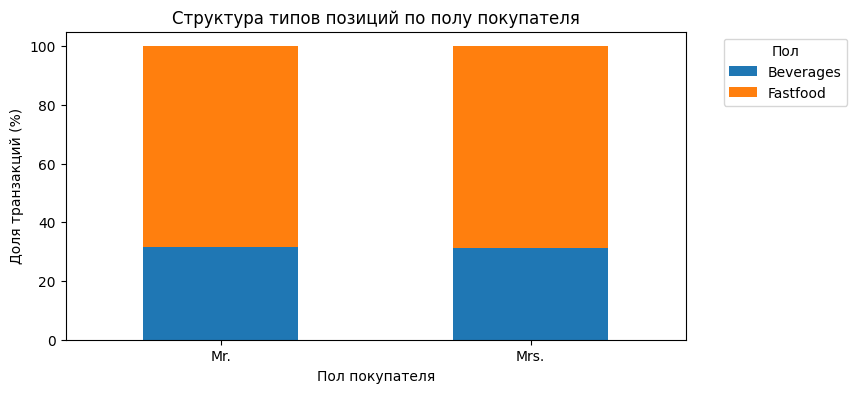

In [13]:
percent_table = pd.crosstab(
    index=orders['received_by'], 
    columns=orders['item_type'], 
    normalize='index' 
) * 100

percent_table.plot(kind='bar', stacked=True, figsize=(8, 4))

plt.title('Структура типов позиций по полу покупателя')
plt.ylabel('Доля транзакций (%)')
plt.xlabel('Пол покупателя')
plt.legend(title='Пол', bbox_to_anchor=(1.05, 1), loc='upper left') # Выносим легенду за график
plt.xticks(rotation=0) 
plt.show()

In [14]:
male_checks_fastfood = orders[(orders['received_by'] == 'Mr.') & (orders['item_type'] == 'Fastfood')]['item_price']
female_checks_fastfood = orders[(orders['received_by'] == 'Mrs.') & (orders['item_type'] == 'Fastfood')]['item_price']

male_checks_beverages = orders[(orders['received_by'] == 'Mr.') & (orders['item_type'] == 'Beverages')]['item_price']
female_checks_beverages = orders[(orders['received_by'] == 'Mrs.') & (orders['item_type'] == 'Beverages')]['item_price']


stat, p_value_fast = stats.mannwhitneyu(male_checks_fastfood, female_checks_fastfood)
stat, p_value_bev = stats.mannwhitneyu(male_checks_beverages, female_checks_beverages)

print(f"p-value fastfood: {p_value_fast:.4f}")
print(f"p-value beverages: {p_value_bev:.4f}")


p-value fastfood: 0.6500
p-value beverages: 0.9017


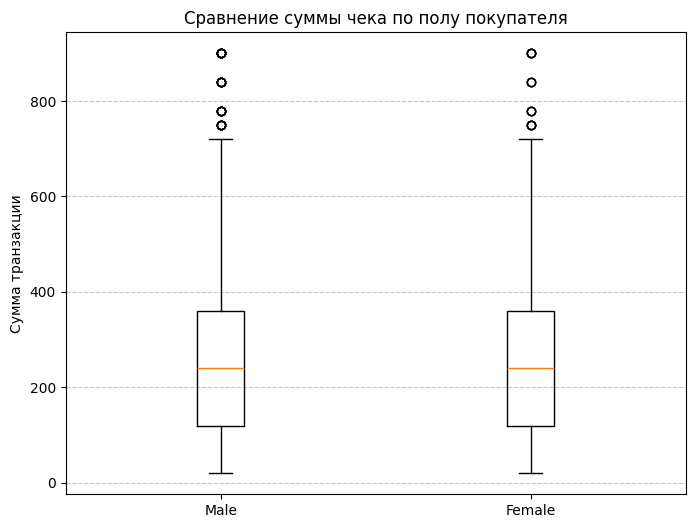

In [15]:
male_amounts = orders[orders['received_by'] == 'Mr.']['transaction_amount']
female_amounts = orders[orders['received_by'] == 'Mrs.']['transaction_amount']

plt.figure(figsize=(8, 6)) 

plt.boxplot([male_amounts, female_amounts], tick_labels=['Male', 'Female'])

plt.title('Сравнение суммы чека по полу покупателя')
plt.ylabel('Сумма транзакции')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Выборка - 893 заказа. 

Вывод: Количество заказов у мужчин больше на 9% в Beverages и на 4% больше в Fastfood, чем у женщин. Доля напитков в заказах женщин на 2% больше, чем у мужчин, а мужчин на 2% больше доля фастфуда. Средняя позиция Beverages в заказах женщин дороже на 7.6%, чем у мужчин. Средняя позиция Fastfood у мужчин дороже на 8.2. 
Разница в среднем чеке для обеих категорий подтверждена критерием Манна-Уитни (p-value < 0.05) 

Рекомендации: 
- Для женского сегмента: сместить фокус с количественных акций на продвижение высокомаржинальных и премиальных напитков. Добавь идею Cross-sell: если женщины берут дорогие напитки, можно на кассе предлагать им легкие закуски к ним.
- Для мужского сегмента: внедрить комбо-предложения («напиток + бургер»), чтобы повысить долю Beverages в их корзине до уровня женского сегмента.

### Временные циклы

##### Гипотеза: Структура заказов  в выходные дни отличается от будней.

In [16]:
def is_weekend(day):
    if day < 5:
        return False
    else:
        return True
orders['is_weekend'] = orders['day_of_week'].apply(is_weekend)

In [17]:
weekday_amount_mean = orders.groupby('is_weekend').transaction_amount.mean()
weekday_quantity_mean = orders.groupby('is_weekend').quantity.mean()
print('Средний чек по дням недели:')
print(weekday_amount_mean)
print('Среднее кол-во товаров в чеке по дням недели:')
weekday_quantity_mean 

Средний чек по дням недели:
is_weekend
False    279.407514
True     265.844156
Name: transaction_amount, dtype: float64
Среднее кол-во товаров в чеке по дням недели:


is_weekend
False    8.239884
True     7.987013
Name: quantity, dtype: float64

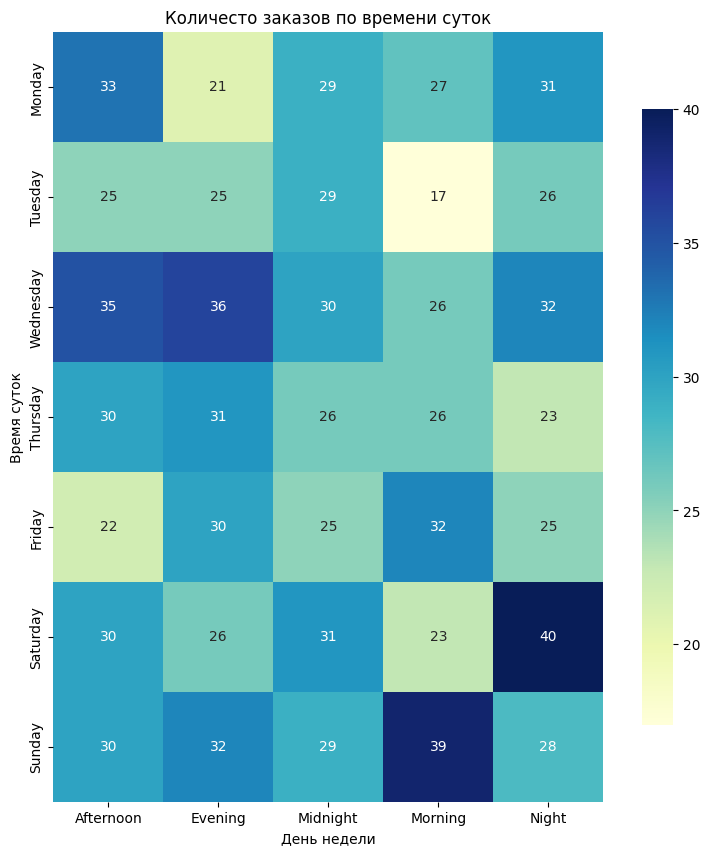

In [18]:
days_order = [
    'Monday', 'Tuesday', 'Wednesday', 
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

for_heat = orders.groupby(['day_of_week_str', 'time_of_sale']).order_id.count().reset_index()
pivot_weekday = for_heat.pivot_table(index='day_of_week_str', columns='time_of_sale', values='order_id', fill_value=0)

pivot_weekday = pivot_weekday.reindex(days_order)

plt.figure(figsize=(10, 10))
sns.heatmap(pivot_weekday, annot=True, fmt='.0f', cmap='YlGnBu', square=True, cbar_kws={"shrink": .8})
plt.title('Количесто заказов по времени суток')
plt.ylabel('Время суток')
plt.xlabel('День недели')
plt.show()

Средний чек по выходным ниже в среднем на 14 денежных единиц относительно будней. Среднее кол-во товаров в чеке по выходным также ниже, на 0.25 единиц товара.

Вывод: заведение пользуется чуть-чуть меньшим спросом в выходные по сравнению с будними. Это нестандартно для фастфуда. Вероятно, точка находится в бизнес-центре или кампусе. 

Рекомендация: Сократить персонал в выходные для оптимизации ФОТ или запустить "Семейные акции" для местных жителей.

## Общий вывод

В ходе анализа выборки из 1000 транзакций ресторана Balaji были выявлены ключевые паттерны потребительского поведения и определены точки роста для увеличения выручки и оптимизации операций.

Главные инсайты:
- Преобладание наличных: Наличный расчет приносит на 8% больше выручки и лидирует в вечерние часы пик, что создает риск замедления обслуживания.
- Гендерные предпочтения: Женский средний чек генерирует больший средний чек в категории напитков (дороже на 7.6%), когда как мужской - в категории фастфуда (дороже на 8.2%).
- Снижение трафика в выходные: Наблюдается нестандартная тенденция - средний чек и количество позиций в чеке по выходным падают (на 14 денежных единиц и 0.25 единиц товара соответственно).

Рекомендации:
- Ускорение обслуживания: Внедрить скидку 2-3% или бонусы за онлайн-оплату в вечернее время (после 17:00), чтобы перевести клиентов на безнал и разгрузить очереди.
- Внедрить кросс-сейл: Запустить комбо-наборы для целевых аудиторий (например, «Сытный бургер + базовый напиток» для мужчин, чтобы повысить продажи напитков в этом сегменте).
- Оптимизировать ФОТ: Сократить количество персонала в утренние смены и в выходные дни соразмерно падению спроса, чтобы сэкономить фонд оплаты труда.